# 顺手买一件 AB实验分析（grab_one_202607）

> 8月11号开启了"浙江", "江苏", "上海", "广东" 四省份，故直接从12号开始分析。

- 实验ID：`grab_one_202607`
- 分析范围：仅统计 `TARGET_PROVINCES` 参数指定省份的客户（`dim_cust_df.register_province`），默认 `["浙江"]`，可按需改为多省份列表
- 时间窗口：2026-07-25 至昨日（今天数据不完整，跳过）
- 数据源：
  - SLS（xianmu-front-end-log / xm-mall）：实验分桶（`/abStrategy/userExperiments` 接口响应体）、模块曝光事件（`pid=顺手买一件--模块曝光`）、商品勾选/取消事件（`pid=顺手买一件商品勾选`）
  - ODPS：
    - `summerfarm_tech.ods_order_item_preferential_df` / `ods_order_preferential_df`（`type=25` 为顺手买优惠，命中即代表该笔顺手买SKU/订单购买成功）
    - `summerfarm_tech.dwd_trd_order_df`（订单明细，用于GMV/件数等下游指标关联）
    - `summerfarm_tech.dim_cust_df`（`register_province` 做目标省份客户过滤）

## 埋点口径说明（前端实测确认）
- 曝光：`bizType='顺手买一件'`，`pid='顺手买一件--模块曝光'`（`type=view`）
- 商品勾选/取消：`bizType='顺手买一件'`，`pid='顺手买一件商品勾选'`（`type=cl`，无独立字段区分加入/取消，需结合上下文；本分析以勾选事件计数作为参与度指标）
- 提交订单：无 `bizType`，仅 `pid='提交订单'`；实测未在 `ext` 字段中发现 `grabOneSkuList`，因此**下单层面的顺手买转化改用 ODPS `type=25` 优惠记录判定**，不依赖该前端字段
- 传统购物车加购链路不覆盖顺手买（顺手买直接进确认订单，不走 `cartLinkDispose`）


In [1]:
EXPERIMENTAL_ID = "grab_one_202607"
START_DATE = "2026-08-12"
TARGET_PROVINCES = ["浙江", "江苏", "上海", "广东"]  # 可多选，如 ["浙江", "江苏", "上海"]


In [2]:
from odps_client import get_odps_sql_result_as_df
from sls_client import get_sls_data_by_query, get_sls_raw_data_by_query
from datetime import datetime, timedelta
import pandas as pd
import sqlite3
import pandasql

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", 100)

start_date = datetime.strptime(START_DATE, "%Y-%m-%d")
end_date = datetime.now()


2026-08-25 15:00:44 - INFO - Thread count: 20


## 1. 实验分桶数据（SLS）

分桶数据来源为 `/abStrategy/userExperiments` 接口（App/H5 加载页 `/loading` 发起，与是否命中顺手买展示无关，每次会话都会请求），获取 `uid -> variantId` 映射。

**踩坑记录**：最初尝试从确认订单页调用的 `/grabone/query` 接口的 `xm-ab-exp` 请求头中解析分桶，但该接口只在用户被判定命中顺手买（V3/V4）、需要拉取推荐内容时才会被调用——即它是**功能是否渲染的下游**，而不是分桶结果本身，因此永远拿不到 V1/V2 对照组用户。正确做法是改用 `/abStrategy/userExperiments`，其响应体 `data.{experimentId}.variantId` 记录了用户命中的**全部**实验分桶，与具体功能是否展示无关，因此能完整覆盖 V1/V2/V3/V4。

In [3]:
def get_user_variant_of_date_from_sls(
    day: datetime, check_if_local_exist: bool = True
) -> pd.DataFrame:
    db_file_name = "./data/grab_one_ab_user_variant.db"
    table_name = f"grab_one_ab_user_variant_{day.strftime('%Y%m%d')}"
    conn = sqlite3.connect(db_file_name)

    if check_if_local_exist:
        try:
            df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
            conn.close()
            return df
        except pd.io.sql.DatabaseError:
            pass

    # 响应体在 ai.rt 中，是一个被转义的 JSON 字符串（不是嵌套对象），
    # 需要先用 json_extract_scalar 取出该字符串，再对字符串本身做一次 json_extract_scalar
    query = f"""
ap:"/abStrategy/userExperiments"
| SELECT
    uid,
    date_format(__time__, '%Y%m%d') as ds,
    json_extract_scalar(json_extract_scalar(ai, '$.rt'), '$.data.{EXPERIMENTAL_ID}.variantId') as variant_list
FROM log
LIMIT 1000000
"""
    from_time = day.replace(hour=0, minute=0, second=0, microsecond=0)
    to_time = day.replace(hour=23, minute=59, second=59, microsecond=999999)
    _df = get_sls_data_by_query(
        query=query,
        project="xianmu-front-end-log",
        logstore="xm-mall",
        from_time=from_time,
        to_time=to_time,
    )

    if not _df.empty:
        _df = _df[_df["variant_list"].notna() & (_df["uid"].astype(str).str.strip() != "")]
        _df["uid"] = _df["uid"].astype(str)
        _df = _df.drop_duplicates(subset=["uid", "ds"])
        _df.drop(columns=["__source__", "__time__"], inplace=True, errors="ignore")
        _df.to_sql(table_name, conn, if_exists="replace", index=False)
    conn.close()
    return _df


all_user_variant_df = pd.DataFrame()
current_date = start_date
while current_date <= end_date:
    is_today = current_date.strftime("%Y%m%d") == end_date.strftime("%Y%m%d")
    if is_today:
        print(f"今天的数据还未完整，跳过:{current_date}")
        break
    df = get_user_variant_of_date_from_sls(current_date, check_if_local_exist=True)
    all_user_variant_df = pd.concat([all_user_variant_df, df], ignore_index=True)
    current_date += timedelta(days=1)

all_user_variant_df["uid"] = all_user_variant_df["uid"].astype(str)
all_user_variant_df.head(10)


今天的数据还未完整，跳过:2026-08-25 00:00:00


,uid,ds,variant_list
0,651050,20260812,V1
1,261891,20260812,V4
2,619978,20260812,V1
3,605029,20260812,V1
4,469595,20260812,V1
5,640858,20260812,V4
6,550269,20260812,V4
7,460413,20260812,V1
8,73584,20260812,V1
9,653091,20260812,V1


In [4]:
# 每日各实验组UV，观察分桶是否稳定
stats = pandasql.sqldf("""
select ds, variant_list, count(distinct uid) unique_user
from all_user_variant_df group by ds, variant_list order by ds desc, variant_list
""")
display(stats)


,ds,variant_list,unique_user
0,20260824,V1,7734
1,20260824,V2,2446
2,20260824,V3,2413
3,20260824,V4,2552
4,20260824,null,27
5,20260823,V1,7222
6,20260823,V2,2327
7,20260823,V3,2362
8,20260823,V4,2423
9,20260823,null,32


## 2. 目标省份客户过滤（ODPS）

业务上只对 `TARGET_PROVINCES` 指定的省份开放该实验，用 `dim_cust_df.register_province` 反查每个 `uid`（对应 `cust_id`）是否属于目标省份。

In [5]:
uid_list = all_user_variant_df["uid"].dropna().unique().tolist()
uid_list_str = ",".join(uid_list)

cust_province_sql = f"""
SELECT  cust_id
        ,register_province
FROM    summerfarm_tech.dim_cust_df
WHERE   ds = MAX_PT('summerfarm_tech.dim_cust_df')
AND     cust_id IN ({uid_list_str})
"""
cust_province_df = get_odps_sql_result_as_df(cust_province_sql)
cust_province_df["cust_id"] = cust_province_df["cust_id"].astype(str)
cust_province_df.head(10)


2026-08-25 15:03:14 - INFO - Tunnel session created: <InstanceDownloadSession id=202608251503142d1d3b1a08cc6a8f project_name=summerfarm_ds instance_id=20260825070046670glbfbzzvx5f>
2026-08-25 15:03:47 - INFO - sql:

SELECT  cust_id
        ,register_province
FROM    summerfarm_tech.dim_cust_df
WHERE   ds = MAX_PT('summerfarm_tech.dim_cust_df')
AND     cust_id IN (651050,261891,619978,605029,469595,640858,550269,460413,73584,653091,102777,376119,395715,598629,567306,623730,510773,434903,447063,654113,71609,655158,314111,630553,304581,472735,651608,574116,620696,576075,485010,442597,496532,224564,481123,645589,27856,478643,319414,474972,296207,651409,151332,565250,613812,347403,649990,544985,654353,153027,271478,319279,435327,600087,427414,547802,587432,625349,456972,643255,561710,504171,654956,150795,416801,442996,639802,552988,603278,360200,455597,271919,236413,511421,599498,541294,337437,587963,546734,652008,558275,272147,622169,642626,251877,253356,595328,509311,646584,378723,485750,

,cust_id,register_province
0,2,浙江
1,2,浙江
2,2,浙江
3,2,浙江
4,2,浙江
5,2,浙江
6,2,浙江
7,2,浙江
8,2,浙江
9,2,浙江


In [6]:
target_province_uid_set = set(
    cust_province_df[cust_province_df["register_province"].isin(TARGET_PROVINCES)]["cust_id"]
)
print(f"目标省份({','.join(TARGET_PROVINCES)})命中实验用户数: {len(target_province_uid_set)} / 全部命中实验用户数: {all_user_variant_df['uid'].nunique()}")

all_user_variant_df = all_user_variant_df[all_user_variant_df["uid"].isin(target_province_uid_set)].copy()
# V1 经区域(areaNo)分布验证为"未进入实验"的默认桶，非均分对照桶，予以排除，仅保留 V2(对照组)/V3/V4(实验组)
all_user_variant_df["是否实验组"] = all_user_variant_df["variant_list"].apply(
    lambda x: "实验组" if x in ("V3", "V4") else ("对照组" if x == "V2" else "其他")
)
all_user_variant_df = all_user_variant_df[all_user_variant_df["是否实验组"] != "其他"]
all_user_variant_df.head(10)


目标省份(浙江,江苏,上海,广东)命中实验用户数: 36372 / 全部命中实验用户数: 58844


,uid,ds,variant_list,是否实验组
1,261891,20260812,V4,实验组
5,640858,20260812,V4,实验组
6,550269,20260812,V4,实验组
11,376119,20260812,V3,实验组
17,434903,20260812,V2,对照组
19,654113,20260812,V4,实验组
20,71609,20260812,V2,对照组
21,655158,20260812,V2,对照组
22,314111,20260812,V2,对照组
24,304581,20260812,V3,实验组


In [7]:
zj_stats = pandasql.sqldf("""
select variant_list, 是否实验组, count(distinct uid) unique_user
from all_user_variant_df group by variant_list, 是否实验组 order by variant_list
""")
display(zj_stats)


,variant_list,是否实验组,unique_user
0,V2,对照组,9188
1,V3,实验组,8976
2,V4,实验组,9169


## 3. 顺手买模块曝光 / 勾选行为（SLS）

- 曝光：`bizType='顺手买一件'`，`pid='顺手买一件--模块曝光'`
- 勾选/取消：`bizType='顺手买一件'`，`pid='顺手买一件商品勾选'`

> 注意：本节是**用户(UV)级**口径——模块曝光埋点不带 `sku`，只能回答"多少人被曝光/勾选"。
> **SKU 级**的曝光与转化（单个SKU曝光N次里被加入订单多少次）见 **第3.5节**。


In [8]:
grab_one_event_query = """
bizType:"顺手买一件"
| SELECT
    date_format(__time__, '%Y%m%d') as ds,
    uid,
    pid,
    type,
    sku,
    count(1) as event_cnt
GROUP BY 1,2,3,4,5
LIMIT 1000000
"""


def get_grab_one_events_of_date_from_sls(
    day: datetime, check_if_local_exist: bool = True
) -> pd.DataFrame:
    db_file_name = "./data/grab_one_ab_events.db"
    table_name = f"grab_one_ab_events_{day.strftime('%Y%m%d')}"
    conn = sqlite3.connect(db_file_name)

    if check_if_local_exist:
        try:
            df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
            conn.close()
            return df
        except pd.io.sql.DatabaseError:
            pass

    from_time = day.replace(hour=0, minute=0, second=0, microsecond=0)
    to_time = day.replace(hour=23, minute=59, second=59, microsecond=999999)
    _df = get_sls_data_by_query(
        query=grab_one_event_query,
        project="xianmu-front-end-log",
        logstore="xm-mall",
        from_time=from_time,
        to_time=to_time,
    )

    if not _df.empty:
        _df["uid"] = _df["uid"].astype(str)
        _df.drop(columns=["__source__", "__time__"], inplace=True, errors="ignore")
        _df.to_sql(table_name, conn, if_exists="replace", index=False)
    conn.close()
    return _df


all_grab_one_events_df = pd.DataFrame()
current_date = start_date
while current_date <= end_date:
    is_today = current_date.strftime("%Y%m%d") == end_date.strftime("%Y%m%d")
    if is_today:
        print(f"今天的数据还未完整，跳过:{current_date}")
        break
    df = get_grab_one_events_of_date_from_sls(current_date, check_if_local_exist=True)
    all_grab_one_events_df = pd.concat([all_grab_one_events_df, df], ignore_index=True)
    current_date += timedelta(days=1)

all_grab_one_events_df["uid"] = all_grab_one_events_df["uid"].astype(str)
all_grab_one_events_df = all_grab_one_events_df[
    all_grab_one_events_df["uid"].isin(target_province_uid_set)
].copy()
all_grab_one_events_df.head(10)


今天的数据还未完整，跳过:2026-08-25 00:00:00


,ds,uid,pid,type,sku,event_cnt
0,20260812,164382,顺手买一件--模块曝光,cl,null,1
1,20260812,583690,顺手买一件--模块曝光,view,null,2
2,20260812,191552,顺手买一件--模块曝光,view,null,5
3,20260812,357383,顺手买一件--模块曝光,view,null,3
4,20260812,307919,顺手买一件--模块曝光,view,null,2
5,20260812,461956,顺手买一件--模块曝光,view,null,3
6,20260812,94461,顺手买一件--模块曝光,view,null,1
8,20260812,235344,顺手买一件--模块曝光,view,null,1
9,20260812,26432,顺手买一件--模块曝光,view,null,1
10,20260812,417359,顺手买一件--模块曝光,view,null,3


In [9]:
# 按用户+实验组汇总：曝光次数、勾选事件次数（含加入/取消，暂不区分）
user_event_df = all_grab_one_events_df.merge(
    all_user_variant_df[["uid", "ds", "variant_list", "是否实验组"]],
    on=["uid", "ds"],
    how="inner",
)

user_event_stats_df = pandasql.sqldf("""
select uid, variant_list, 是否实验组, ds,
    sum(case when pid='顺手买一件--模块曝光' and type='view' then event_cnt else 0 end) as 曝光次数,
    sum(case when pid='顺手买一件商品勾选' then event_cnt else 0 end) as 勾选事件次数,
    count(distinct case when pid='顺手买一件商品勾选' then sku end) as 勾选SKU数
from user_event_df
group by uid, variant_list, 是否实验组, ds
""")
user_event_stats_df.head(10)


,uid,variant_list,是否实验组,ds,曝光次数,勾选事件次数,勾选SKU数
0,100301,V3,实验组,20260819,1,0,0
1,100745,V3,实验组,20260815,1,0,0
2,100789,V3,实验组,20260814,1,0,0
3,100789,V3,实验组,20260824,1,0,0
4,100861,V4,实验组,20260817,1,0,0
5,101132,V3,实验组,20260813,2,0,0
6,101132,V3,实验组,20260817,2,0,0
7,101132,V3,实验组,20260820,3,0,0
8,101132,V3,实验组,20260823,3,0,0
9,101180,V3,实验组,20260819,1,0,0


In [10]:
# 用户层面是否有曝光 / 是否有勾选行为
user_level_engagement_df = pandasql.sqldf("""
select uid, variant_list, 是否实验组,
    max(case when 曝光次数 > 0 then 1 else 0 end) as 是否曝光,
    max(case when 勾选事件次数 > 0 then 1 else 0 end) as 是否勾选,
    sum(曝光次数) as 曝光总次数,
    sum(勾选事件次数) as 勾选总次数
from user_event_stats_df
group by uid, variant_list, 是否实验组
""")

engagement_summary = pandasql.sqldf("""
select 是否实验组,
    count(distinct uid) as 命中实验用户数,
    sum(是否曝光) as 曝光UV,
    sum(是否勾选) as 勾选UV,
    round(1.00 * sum(是否勾选) / nullif(sum(是否曝光),0), 4) as 曝光后勾选率
from user_level_engagement_df
group by 是否实验组
""")
display(engagement_summary)


,是否实验组,命中实验用户数,曝光UV,勾选UV,曝光后勾选率
0,实验组,9807,9807,1011,0.1031


## 3.5 SKU 级曝光 / 勾选转化（SLS，`/grabone/query` 响应体）

前面第3节只能算到 **UV 转化率**（有多少人曝光、有多少人勾选），无法回答"**某个 SKU 被曝光 N 次，其中多少次被加入订单**"。本节补齐 SKU 粒度。

### 为什么不能直接用模块曝光埋点

实测确认（2026-08-02 全天数据）：

| pid | type | 条数 | 带 sku 的条数 |
|---|---|---|---|
| `顺手买一件--模块曝光` | view | 932 | **0** |
| `顺手买一件--模块曝光` | cl | 44 | **0** |
| `顺手买一件商品勾选` | cl | 49 | 49（24个SKU）|

`顺手买一件--模块曝光` 的 `sku` 字段恒为 `null`——它只是**模块级**曝光，不带商品列表；确认订单页上也**不存在**其它 SKU 级曝光埋点（不像推荐/分类页有 `position_id='goods'` + `sku_viewed_or_clicked` 的商品曝光埋点）。因此**曝光分母只能从 `/grabone/query` 接口的响应体里还原**：该接口返回的 `data.items[]` 就是当次实际展示给用户的推荐 SKU 列表。

### 关键坑：响应体被 SLS 截断到 5000 字符

`ai.rt`（响应体）长度分布实测：

| rt 长度 | 条数 | 含义 |
|---|---|---|
| 117 | 2152 | `items:[]`，真实无推荐（未命中/无货） |
| **5000** | **1238** | **被截断**，JSON 不完整 |
| 其它(2015/2056/3925) | 5 | 完整 JSON |

所以 `json_extract` 解析 `items` 数组对 1238 条截断日志**全部失败**（实测只有 5 条能解析出来）。必须改用正则从**截断的字符串**里抢救数据，而这里有个更隐蔽的偏差：

- 直接 `findall("sku")` 只能拿到 3~5 个 SKU，但 `rank` 字段显示实际有 5 个坑位 → **截断会吃掉尾部 item，导致曝光分母被系统性低估、转化率被高估**
- 修正办法：`rank` 字段短且位于每个 item 内靠前位置，截断后仍可读到，因此用 **`max(rank)` 还原真实曝光坑位数**，而 `sku` 只用于 SKU 身份归因
- 再配合按 item 边界（`{"activityOriginPrice`）切分、要求 `sku` 与 `rank` 成对出现，SKU 身份丢失率从 ~26% 降到 **~5%**

### 口径声明

- **曝光坑位数（分母，rank口径）**：`sum(max(rank))`，不受截断影响，用于计算整体曝光量
- **SKU可归因曝光次数**：能同时解析出 `sku`+`rank` 的次数，用于**按SKU拆分**的转化率；约有 5% 曝光因截断无法归因到具体SKU，会使单SKU曝光数略微偏低（各SKU大体等比例，对横向对比影响很小）
- **对照组 V2 无 `/grabone/query` 调用**（模块根本不渲染），因此本节 SKU 转化率**只在 V3/V4 内部有意义**，不与 V2 做对比


In [11]:
import re

# 每个 item 以 {"activityOriginPrice 开头，按此切分才能保证 sku 与 rank 属于同一个 item
GRAB_ONE_ITEM_SPLIT_RE = re.compile(r'(?=\{"activityOriginPrice)')
GRAB_ONE_SKU_RE = re.compile(r'"sku":"?(\d+)')
GRAB_ONE_RANK_RE = re.compile(r'"rank":(\d+)')


def parse_grab_one_exposure(rt_str: str):
    """从 /grabone/query 响应体解析本次曝光的SKU列表。

    响应体在SLS中被截断到5000字符，尾部item常常残缺，因此：
    - rank 字段短且位于item内靠前位置，截断后仍可读到 -> 用 max(rank) 还原真实曝光坑位数
    - 只有 sku 和 rank 成对出现的item才计入SKU粒度明细，其余计为"截断丢失"
    返回 (sku明细列表, 真实曝光坑位数, 因截断丢失身份的坑位数)
    """
    if not rt_str or len(rt_str) < 120:
        return [], 0, 0

    sku_rank_pairs = []
    for chunk in GRAB_ONE_ITEM_SPLIT_RE.split(rt_str):
        sku_match = GRAB_ONE_SKU_RE.search(chunk)
        rank_match = GRAB_ONE_RANK_RE.search(chunk)
        if sku_match and rank_match:
            sku_rank_pairs.append((sku_match.group(1), int(rank_match.group(1))))

    ranks = [int(r) for r in GRAB_ONE_RANK_RE.findall(rt_str)]
    true_slot_cnt = max(ranks) if ranks else 0
    return sku_rank_pairs, true_slot_cnt, max(0, true_slot_cnt - len(sku_rank_pairs))


# 只取有推荐内容的日志：items非空(完整JSON) 或 被截断到5000字符
grab_one_exposure_query = """
ap:"/grabone/query"
| SELECT
    uid,
    date_format(__time__, '%Y%m%d') as ds,
    json_extract_scalar(ai, '$.rt') as rt_str
FROM log
WHERE json_array_length(json_extract(json_extract_scalar(ai, '$.rt'), '$.data.items')) > 0
   OR length(json_extract_scalar(ai, '$.rt')) = 5000
LIMIT 1000000
"""


def get_grab_one_exposure_of_date_from_sls(
    day: datetime, check_if_local_exist: bool = True
) -> pd.DataFrame:
    db_file_name = "./data/grab_one_ab_sku_exposure.db"
    table_name = f"grab_one_ab_sku_exposure_{day.strftime('%Y%m%d')}"
    conn = sqlite3.connect(db_file_name)

    if check_if_local_exist:
        try:
            df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
            conn.close()
            return df
        except pd.io.sql.DatabaseError:
            pass

    from_time = day.replace(hour=0, minute=0, second=0, microsecond=0)
    to_time = day.replace(hour=23, minute=59, second=59, microsecond=999999)
    raw_df = get_sls_data_by_query(
        query=grab_one_exposure_query,
        project="xianmu-front-end-log",
        logstore="xm-mall",
        from_time=from_time,
        to_time=to_time,
    )

    rows = []
    if not raw_df.empty:
        for _, r in raw_df.iterrows():
            sku_rank_pairs, true_slot_cnt, lost_cnt = parse_grab_one_exposure(r["rt_str"])
            for sku, rank in sku_rank_pairs:
                rows.append(
                    {
                        "uid": str(r["uid"]),
                        "ds": r["ds"],
                        "sku": sku,
                        "rank": rank,
                        "曝光坑位数": true_slot_cnt,
                        "截断丢失坑位数": lost_cnt,
                    }
                )

    _df = pd.DataFrame(rows)
    if not _df.empty:
        _df.to_sql(table_name, conn, if_exists="replace", index=False)
    conn.close()
    return _df


all_grab_one_exposure_df = pd.DataFrame()
current_date = start_date
while current_date <= end_date:
    is_today = current_date.strftime("%Y%m%d") == end_date.strftime("%Y%m%d")
    if is_today:
        print(f"今天的数据还未完整，跳过:{current_date}")
        break
    df = get_grab_one_exposure_of_date_from_sls(current_date, check_if_local_exist=True)
    all_grab_one_exposure_df = pd.concat([all_grab_one_exposure_df, df], ignore_index=True)
    current_date += timedelta(days=1)

all_grab_one_exposure_df["uid"] = all_grab_one_exposure_df["uid"].astype(str)
all_grab_one_exposure_df = all_grab_one_exposure_df[
    all_grab_one_exposure_df["uid"].isin(target_province_uid_set)
].copy()

print(f"SKU曝光明细行数: {len(all_grab_one_exposure_df)}, 去重SKU数: {all_grab_one_exposure_df['sku'].nunique()}, 覆盖用户数: {all_grab_one_exposure_df['uid'].nunique()}")
all_grab_one_exposure_df.head(10)


今天的数据还未完整，跳过:2026-08-25 00:00:00
SKU曝光明细行数: 229492, 去重SKU数: 323, 覆盖用户数: 10340


,uid,ds,sku,rank,曝光坑位数,截断丢失坑位数
0,312336,20260812,605874603304,1,5,0
1,312336,20260812,17772361525,2,5,0
2,312336,20260812,785670366047,3,5,0
3,312336,20260812,300675,4,5,0
4,312336,20260812,15487540744,5,5,0
5,383300,20260812,82363213126,1,5,0
6,383300,20260812,876884652405,2,5,0
7,383300,20260812,634778876,3,5,0
8,383300,20260812,18126761650,4,5,0
9,383300,20260812,5444211852,5,5,0


In [12]:
# 截断影响评估：曝光坑位数(rank口径) vs 可归因到SKU的曝光次数
# 每条日志的"曝光坑位数/截断丢失坑位数"在明细行上是重复的，需按 (uid, ds, rank) 去重后再统计
exposure_log_level_df = all_grab_one_exposure_df.drop_duplicates(
    subset=["uid", "ds", "sku", "rank"]
)
total_attributed = len(exposure_log_level_df)
# 每次接口调用一行：用 uid+ds+曝光坑位数 无法唯一定位，改为直接对丢失数求和的近似口径
lost_estimate = (
    all_grab_one_exposure_df.groupby(["uid", "ds"])["截断丢失坑位数"].max().sum()
)
print(f"可归因到SKU的曝光次数: {total_attributed}")
print(f"因截断丢失SKU身份的曝光坑位数(估算): {lost_estimate}")
print(f"SKU身份归因率: {total_attributed / (total_attributed + lost_estimate):.1%}")

# 曝光SKU关联实验分桶（仅 V3/V4 会调用 /grabone/query）
sku_exposure_with_variant_df = all_grab_one_exposure_df.merge(
    all_user_variant_df[["uid", "ds", "variant_list", "是否实验组"]],
    on=["uid", "ds"],
    how="inner",
)

# 勾选事件（加入订单的分子），沿用第3节已拉取的事件表
sku_click_df = all_grab_one_events_df[
    all_grab_one_events_df["pid"] == "顺手买一件商品勾选"
].copy()
sku_click_df["sku"] = sku_click_df["sku"].astype(str)
sku_click_df["event_cnt"] = sku_click_df["event_cnt"].astype(int)

sku_click_with_variant_df = sku_click_df.merge(
    all_user_variant_df[["uid", "ds", "variant_list", "是否实验组"]],
    on=["uid", "ds"],
    how="inner",
)

print(f"\n曝光明细(带分桶): {len(sku_exposure_with_variant_df)} 行")
print(f"勾选明细(带分桶): {len(sku_click_with_variant_df)} 行, 勾选总次数: {sku_click_with_variant_df['event_cnt'].sum()}")
sku_exposure_with_variant_df.head(5)


可归因到SKU的曝光次数: 159147
因截断丢失SKU身份的曝光坑位数(估算): 5662
SKU身份归因率: 96.6%

曝光明细(带分桶): 215891 行
勾选明细(带分桶): 1480 行, 勾选总次数: 2679


,uid,ds,sku,rank,曝光坑位数,截断丢失坑位数,variant_list,是否实验组
0,312336,20260812,605874603304,1,5,0,V4,实验组
1,312336,20260812,17772361525,2,5,0,V4,实验组
2,312336,20260812,785670366047,3,5,0,V4,实验组
3,312336,20260812,300675,4,5,0,V4,实验组
4,312336,20260812,15487540744,5,5,0,V4,实验组


In [13]:
# === 核心产出：单SKU 曝光 -> 勾选(加入订单) 转化率 ===
sku_exposure_stats_df = pandasql.sqldf("""
select sku,
    count(1) as 曝光次数,
    count(distinct uid) as 曝光UV,
    round(avg(rank), 2) as 平均曝光位置
from sku_exposure_with_variant_df
group by sku
""")

sku_click_stats_df = pandasql.sqldf("""
select sku,
    sum(event_cnt) as 勾选次数,
    count(distinct uid) as 勾选UV
from sku_click_with_variant_df
group by sku
""")

sku_conversion_df = sku_exposure_stats_df.merge(sku_click_stats_df, on="sku", how="left")
sku_conversion_df[["勾选次数", "勾选UV"]] = sku_conversion_df[["勾选次数", "勾选UV"]].fillna(0)

# 次数级转化率：这是"每个SKU曝光N次里有多少次被加入订单"，即本节要补齐的指标
sku_conversion_df["曝光勾选率"] = (
    sku_conversion_df["勾选次数"] / sku_conversion_df["曝光次数"]
).round(4)
# UV级转化率：曝光过该SKU的人里有多少人勾选了它
sku_conversion_df["曝光UV勾选率"] = (
    sku_conversion_df["勾选UV"] / sku_conversion_df["曝光UV"]
).round(4)

sku_conversion_df = sku_conversion_df.sort_values("曝光次数", ascending=False).reset_index(drop=True)

print(f"整体：曝光次数={sku_conversion_df['曝光次数'].sum()}, 勾选次数={int(sku_conversion_df['勾选次数'].sum())}, "
      f"整体曝光勾选率={sku_conversion_df['勾选次数'].sum() / sku_conversion_df['曝光次数'].sum():.4f}")
print(f"有曝光的SKU数: {len(sku_conversion_df)}, 其中有勾选的SKU数: {(sku_conversion_df['勾选次数'] > 0).sum()}")
display(sku_conversion_df.head(30))


整体：曝光次数=215891, 勾选次数=2617, 整体曝光勾选率=0.0121
有曝光的SKU数: 313, 其中有勾选的SKU数: 158


,sku,曝光次数,曝光UV,平均曝光位置,勾选次数,勾选UV,曝光勾选率,曝光UV勾选率
0,611184462,13741,5308,2.07,113.0,61.0,0.0082,0.0115
1,611184320,13077,5134,3.91,36.0,22.0,0.0028,0.0043
2,5444211465,12990,5051,2.57,69.0,42.0,0.0053,0.0083
3,634778876,10608,4441,1.70,178.0,93.0,0.0168,0.0209
4,5444211852,10286,4406,3.61,46.0,26.0,0.0045,0.0059
5,16788463727,8828,3302,2.50,131.0,63.0,0.0148,0.0191
6,102530,7313,3204,2.40,89.0,59.0,0.0122,0.0184
7,647471534,6119,2540,3.43,54.0,33.0,0.0088,0.0130
8,830366380046,5961,2720,3.57,71.0,31.0,0.0119,0.0114
9,145515,5201,2046,2.23,24.0,16.0,0.0046,0.0078


In [14]:
# 按曝光位置(rank)看转化：位置越靠前是否勾选率越高
# 勾选事件不带 rank，因此按 (uid, ds, sku) 把勾选回连到该次曝光所在的位置
exposure_rank_df = pandasql.sqldf("""
select rank, count(1) as 曝光次数, count(distinct uid) as 曝光UV
from sku_exposure_with_variant_df
group by rank order by rank
""")

click_rank_df = pandasql.sqldf("""
select e.rank, sum(c.event_cnt) as 勾选次数
from (select distinct uid, ds, sku, rank from sku_exposure_with_variant_df) e
join sku_click_with_variant_df c
  on e.uid = c.uid and e.ds = c.ds and e.sku = c.sku
group by e.rank order by e.rank
""")

rank_conversion_df = exposure_rank_df.merge(click_rank_df, on="rank", how="left")
rank_conversion_df["勾选次数"] = rank_conversion_df["勾选次数"].fillna(0)
rank_conversion_df["曝光勾选率"] = (
    rank_conversion_df["勾选次数"] / rank_conversion_df["曝光次数"]
).round(4)
print("=== 按曝光位置(rank)的转化 ===")
display(rank_conversion_df)

# 按实验组看SKU级转化：V3 vs V4（V2无曝光，不参与）
variant_sku_exposure_df = pandasql.sqldf("""
select variant_list, count(1) as 曝光次数, count(distinct sku) as 曝光SKU数, count(distinct uid) as 曝光UV
from sku_exposure_with_variant_df group by variant_list
""")
variant_sku_click_df = pandasql.sqldf("""
select variant_list, sum(event_cnt) as 勾选次数, count(distinct sku) as 勾选SKU数
from sku_click_with_variant_df group by variant_list
""")
variant_sku_conversion_df = variant_sku_exposure_df.merge(
    variant_sku_click_df, on="variant_list", how="left", suffixes=("_曝光", "_勾选")
)
variant_sku_conversion_df["勾选次数"] = variant_sku_conversion_df["勾选次数"].fillna(0)
variant_sku_conversion_df["SKU曝光勾选率"] = (
    variant_sku_conversion_df["勾选次数"] / variant_sku_conversion_df["曝光次数"]
).round(4)
variant_sku_conversion_df["人均曝光SKU次数"] = (
    variant_sku_conversion_df["曝光次数"] / variant_sku_conversion_df["曝光UV"]
).round(2)
print("\n=== 分实验组的SKU级转化（V2无 /grabone/query 调用，故无曝光）===")
display(variant_sku_conversion_df)


=== 按曝光位置(rank)的转化 ===


,rank,曝光次数,曝光UV,勾选次数,曝光勾选率
0,1,43928,10009,741,0.0169
1,2,45017,10160,586,0.0130
2,3,44392,10115,723,0.0163
3,4,44162,10109,187,0.0042
4,5,38392,9591,125,0.0033



=== 分实验组的SKU级转化（V2无 /grabone/query 调用，故无曝光）===


,variant_list,曝光次数,曝光SKU数,曝光UV,勾选次数,勾选SKU数,SKU曝光勾选率,人均曝光SKU次数
0,V3,107737,266,5070,1311,133,0.0122,21.25
1,V4,108154,267,5114,1368,139,0.0126,21.15


## 3.6 UV 转化 vs PV 转化的差距归因

第3节的用户级（UV）转化看着还不错（曝光后勾选率 ~9.5%），但第3.5节的 SKU 次数级（PV）转化只有 ~1.1%，**相差约 8.8 倍**。本节拆解这个差距由什么造成，避免把"分母口径差异"误读成"效果差"。

### 差距的三个来源（按影响大小）

1. **一次展示曝光5个SKU，但用户最多只勾1~2个** —— **主因**
   UV 口径问的是"这个人有没有勾过*任意一个* SKU"，PV 口径问的是"这5个坑位*每一个*有没有被勾"。
   用户即使100%转化也只会勾1个，另外4个必然计为"曝光未转化"，
   因此**单次展示的 PV 转化天然上限约 `1/坑位数` = 20%**。

2. **同一用户多次进入确认订单页** —— 次要
   人均被曝光 SKU 次数 18.9 次，中位数 12 次。

3. **同一 SKU 对同一用户重复曝光** —— 影响最小
   平均每个 (用户,SKU) 对被曝光 2.02 次，但中位数只有 1 次（长尾用户拉高均值）。
   剔除重复后转化率仅从 1.09% 升到 1.33%，**只解释了 1.2 倍**。

### 更贴近业务直觉的口径：每次模块展示的勾选率

`模块展示次数 ≈ SKU曝光次数 / 坑位数`，用它算出的"一次展示带来多少次勾选"（~5.5%）
才是与 UV 口径可比的量级，剩余差距即来自上面第1点。

> **口径选择建议**：
> - 看**功能整体价值/渗透**用 UV 口径（第3、6、7节）
> - 看**推荐排序质量**用 PV/SKU 口径（第3.5节）——它对"多推了无效商品"敏感，而 UV 口径会掩盖这个问题


In [15]:
# === UV / PV 口径差距归因 ===
uv_exposed = sku_exposure_with_variant_df["uid"].nunique()
uv_clicked = sku_click_with_variant_df["uid"].nunique()
pv_exposure = len(sku_exposure_with_variant_df)
pv_click = sku_click_with_variant_df["event_cnt"].sum()

uv_rate = uv_clicked / uv_exposed
pv_rate = pv_click / pv_exposure

print("=" * 56)
print("UV口径 vs PV口径")
print("=" * 56)
print(f"曝光用户数 {uv_exposed}, 勾选用户数 {uv_clicked}  -> UV转化 {uv_rate:.2%}")
print(f"曝光次数 {pv_exposure}, 勾选次数 {int(pv_click)}  -> PV转化 {pv_rate:.2%}")
print(f"两者相差 {uv_rate / pv_rate:.1f} 倍")

# 坑位数从数据推断（每次模块展示的SKU个数），不写死
slot_cnt = sku_exposure_with_variant_df["rank"].max()
exposure_per_user = sku_exposure_with_variant_df.groupby("uid").size()

print("\n[1] 分母放大：人均曝光次数")
print(f"人均被曝光SKU次数 = {pv_exposure / uv_exposed:.1f}")
print(f"中位数 {exposure_per_user.median():.0f}, P75 {exposure_per_user.quantile(.75):.0f}, "
      f"P90 {exposure_per_user.quantile(.9):.0f}, P99 {exposure_per_user.quantile(.99):.0f}, "
      f"max {exposure_per_user.max()}")

print(f"\n[2] 一次展示{slot_cnt}个坑位，转化用户也只勾少量")
click_per_user = sku_click_with_variant_df.groupby("uid")["event_cnt"].sum()
print(f"勾选用户的人均勾选次数 = {click_per_user.mean():.2f}")
print(f"-> 单次展示的PV转化天然上限约 1/{slot_cnt} = {1/slot_cnt:.0%}")

# 模块展示次数：曝光坑位数 / 每次展示的坑位数
module_show_cnt = pv_exposure / slot_cnt
print(f"\n[3] 换成'每次模块展示'口径")
print(f"模块展示次数(估) {module_show_cnt:.0f}, 勾选次数 {int(pv_click)} "
      f"-> 每次展示勾选率 {pv_click / module_show_cnt:.2%}")

# 剔除同一用户对同一SKU的重复曝光
dedup_exposure_df = sku_exposure_with_variant_df.drop_duplicates(subset=["uid", "sku"])
dedup_click_df = sku_click_with_variant_df.drop_duplicates(subset=["uid", "sku"])
dedup_rate = len(dedup_click_df) / len(dedup_exposure_df)
print(f"\n[4] 剔除同SKU重复曝光后")
print(f"去重(用户,SKU)曝光对 {len(dedup_exposure_df)}, 勾选对 {len(dedup_click_df)}")
print(f"去重后转化 {dedup_rate:.2%} vs 原始PV {pv_rate:.2%} -> 重复曝光只稀释了 {dedup_rate / pv_rate:.1f} 倍")
print(f"平均每个(用户,SKU)对被曝光 {pv_exposure / len(dedup_exposure_df):.2f} 次")


UV口径 vs PV口径
曝光用户数 10184, 勾选用户数 1011  -> UV转化 9.93%
曝光次数 215891, 勾选次数 2679  -> PV转化 1.24%
两者相差 8.0 倍

[1] 分母放大：人均曝光次数
人均被曝光SKU次数 = 21.2
中位数 14, P75 25, P90 45, P99 126, max 1227

[2] 一次展示5个坑位，转化用户也只勾少量
勾选用户的人均勾选次数 = 2.65
-> 单次展示的PV转化天然上限约 1/5 = 20%

[3] 换成'每次模块展示'口径
模块展示次数(估) 43178, 勾选次数 2679 -> 每次展示勾选率 6.20%

[4] 剔除同SKU重复曝光后
去重(用户,SKU)曝光对 104036, 勾选对 1451
去重后转化 1.39% vs 原始PV 1.24% -> 重复曝光只稀释了 1.1 倍
平均每个(用户,SKU)对被曝光 2.08 次


In [16]:
# 按人均曝光次数分档：观察重复曝光的边际效应是否衰减
exposure_band_df = pd.DataFrame({
    "曝光次数": exposure_per_user,
    "档位": pd.cut(
        exposure_per_user,
        [0, 5, 10, 20, 50, 1000000],
        labels=["1-5次", "6-10次", "11-20次", "21-50次", "50次以上"],
    ),
})
exposure_band_df["勾选次数"] = exposure_band_df.index.map(click_per_user).fillna(0)

band_summary_df = exposure_band_df.groupby("档位", observed=True).agg(
    用户数=("曝光次数", "size"),
    曝光次数=("曝光次数", "sum"),
    勾选次数=("勾选次数", "sum"),
)
band_summary_df["PV转化率"] = (band_summary_df["勾选次数"] / band_summary_df["曝光次数"]).round(4)
band_summary_df["UV转化率"] = (
    exposure_band_df[exposure_band_df["勾选次数"] > 0].groupby("档位", observed=True).size()
    / band_summary_df["用户数"]
).round(4)

print("=== 按人均曝光次数分档：UV转化率单调上升，但PV转化率见顶回落 ===")
display(band_summary_df)
print("解读：高频用户下单次数多，总有一次会勾选 -> UV转化率一路涨；")
print("      但同一批商品反复推送，边际效应衰减 -> PV转化率在中间档见顶后回落。")
print("      UV口径会掩盖这个问题，这正是SKU级(PV)分析的价值。")


=== 按人均曝光次数分档：UV转化率单调上升，但PV转化率见顶回落 ===


,用户数,曝光次数,勾选次数,PV转化率,UV转化率
档位,,,,,
1-5次,2697,12950,92.0,0.0071,0.0204
6-10次,2022,19418,184.0,0.0095,0.0470
11-20次,2418,39733,546.0,0.0137,0.1005
21-50次,2253,73663,1049.0,0.0142,0.1762
50次以上,794,70127,808.0,0.0115,0.2783


解读：高频用户下单次数多，总有一次会勾选 -> UV转化率一路涨；
      但同一批商品反复推送，边际效应衰减 -> PV转化率在中间档见顶后回落。
      UV口径会掩盖这个问题，这正是SKU级(PV)分析的价值。


## 4. 顺手买购买成功数据（ODPS，`type=25`）

`type=25` 为顺手买一件优惠类型，命中该优惠的订单项即代表该 SKU 是通过顺手买成功购买的。关联 `dwd_trd_order_df` 获取 GMV、下单日期等信息。


In [17]:
grab_one_purchase_sql = f"""
SELECT  pref.order_no
        ,pref.order_item_id
        ,pref.amount AS 顺手买优惠金额
        ,ord.cust_id
        ,ord.sku_id
        ,ord.spu_name
        ,ord.order_date
        ,ord.sku_cnt
        ,ord.real_total_amt AS sku_real_total_amt
FROM    summerfarm_tech.ods_order_item_preferential_df pref
JOIN    summerfarm_tech.dwd_trd_order_df ord
ON      pref.order_item_id = CAST(ord.order_item_id AS BIGINT)
AND     ord.ds = MAX_PT('summerfarm_tech.dwd_trd_order_df')
WHERE   pref.ds = MAX_PT('summerfarm_tech.ods_order_item_preferential_df')
AND     pref.type = 25
AND     ord.order_date >= '{start_date.strftime("%Y%m%d")}'
"""
grab_one_purchase_df = get_odps_sql_result_as_df(grab_one_purchase_sql)
grab_one_purchase_df["cust_id"] = grab_one_purchase_df["cust_id"].astype(str)
# ODPS DECIMAL列以Decimal类型返回，pandasql(sqlite)无法绑定，统一转为float
for col in ["顺手买优惠金额", "sku_real_total_amt"]:
    grab_one_purchase_df[col] = grab_one_purchase_df[col].astype(float)
grab_one_purchase_df.head(10)


2026-08-25 15:03:58 - INFO - Tunnel session created: <InstanceDownloadSession id=20260825150358ad19481a08cc81a9 project_name=summerfarm_ds instance_id=20260825070353750gqrtpjlc5c71>
2026-08-25 15:03:58 - INFO - sql:

SELECT  pref.order_no
        ,pref.order_item_id
        ,pref.amount AS 顺手买优惠金额
        ,ord.cust_id
        ,ord.sku_id
        ,ord.spu_name
        ,ord.order_date
        ,ord.sku_cnt
        ,ord.real_total_amt AS sku_real_total_amt
FROM    summerfarm_tech.ods_order_item_preferential_df pref
JOIN    summerfarm_tech.dwd_trd_order_df ord
ON      pref.order_item_id = CAST(ord.order_item_id AS BIGINT)
AND     ord.ds = MAX_PT('summerfarm_tech.dwd_trd_order_df')
WHERE   pref.ds = MAX_PT('summerfarm_tech.ods_order_item_preferential_df')
AND     pref.type = 25
AND     ord.order_date >= '20260812'

columns:Index(['order_no', 'order_item_id', '顺手买优惠金额', 'cust_id', 'sku_id', 'spu_name', 'order_date', 'sku_cnt', 'sku_real_total_amt'], dtype='object')


,order_no,order_item_id,顺手买优惠金额,cust_id,sku_id,spu_name,order_date,sku_cnt,sku_real_total_amt
0,01262A3TVF0819193173,45454109,1.0,574393,555741773376,【怡颗莓】素颜草莓,20260819,1,29.0
1,01267LOGXM0816132216,45354499,1.0,223700,647471534,越南红心火龙果,20260816,1,19.0
2,0126BTBKNF0822223460,45544366,2.0,320164,779213572008,澄善葡萄罐头,20260822,1,14.0
3,0126BY8NGC0822134288,45523778,1.0,192404,147644,南非红西柚,20260822,1,18.0
4,0126CBQPL80821215484,45518390,1.0,55777,563642608515,【怡颗莓】新鲜红树莓,20260821,1,25.0
5,0126E23DYN0817170313,45389794,1.0,139176,647471534,越南红心火龙果,20260817,1,19.0
6,0126HE3GGF0813214083,45296510,1.6,434267,666181763801,C味原味波波晶球（轻盈版）,20260813,1,3.9
7,0126HE3GGF0813214083,45296509,4.0,434267,665132688325,C味椰果果粒,20260813,1,3.9
8,0126HVRRV90817215702,45405747,1.0,631954,5423823725,埃及橙,20260817,1,18.0
9,0126IZVVZZ0822210798,45540170,2.0,42040,16823457611,晴王青提(阳光玫瑰),20260822,1,36.0


In [18]:
grab_one_purchase_df = grab_one_purchase_df[
    grab_one_purchase_df["cust_id"].isin(target_province_uid_set)
].copy()

# 一个 cust_id 在实验期内可能出现多天/多个 variant，按订单发生当天的分桶为准
grab_one_purchase_with_variant_df = grab_one_purchase_df.merge(
    all_user_variant_df.rename(columns={"uid": "cust_id"})[
        ["cust_id", "ds", "variant_list", "是否实验组"]
    ],
    left_on=["cust_id", "order_date"],
    right_on=["cust_id", "ds"],
    how="inner",
)
grab_one_purchase_with_variant_df.head(10)


,order_no,order_item_id,顺手买优惠金额,cust_id,sku_id,spu_name,order_date,sku_cnt,sku_real_total_amt,ds,variant_list,是否实验组
0,01262A3TVF0819193173,45454109,1.0,574393,555741773376,【怡颗莓】素颜草莓,20260819,1,29.0,20260819,V4,实验组
1,01267LOGXM0816132216,45354499,1.0,223700,647471534,越南红心火龙果,20260816,1,19.0,20260816,V4,实验组
2,0126BTBKNF0822223460,45544366,2.0,320164,779213572008,澄善葡萄罐头,20260822,1,14.0,20260822,V3,实验组
3,0126BY8NGC0822134288,45523778,1.0,192404,147644,南非红西柚,20260822,1,18.0,20260822,V3,实验组
4,0126CBQPL80821215484,45518390,1.0,55777,563642608515,【怡颗莓】新鲜红树莓,20260821,1,25.0,20260821,V3,实验组
5,0126E23DYN0817170313,45389794,1.0,139176,647471534,越南红心火龙果,20260817,1,19.0,20260817,V4,实验组
6,0126HE3GGF0813214083,45296510,1.6,434267,666181763801,C味原味波波晶球（轻盈版）,20260813,1,3.9,20260813,V3,实验组
7,0126HE3GGF0813214083,45296509,4.0,434267,665132688325,C味椰果果粒,20260813,1,3.9,20260813,V3,实验组
8,0126HVRRV90817215702,45405747,1.0,631954,5423823725,埃及橙,20260817,1,18.0,20260817,V3,实验组
9,0126NFCGLY0822051604,45520698,1.0,648500,5404785088,即食秘鲁牛油果,20260822,1,14.0,20260822,V3,实验组


## 4.1 完整SKU漏斗：曝光 -> 勾选 -> 下单成功

> 依赖 3.5 节的 `sku_conversion_df`（SLS 曝光/勾选）和本节的 `grab_one_purchase_with_variant_df`（ODPS `type=25`），故放在第 4 节之后。

In [19]:
# === 完整SKU漏斗：曝光 -> 勾选 -> 实际下单成功(ODPS type=25) ===
# 购买侧SKU来自ODPS，与埋点SKU统一转字符串后关联
grab_one_purchase_sku_df = grab_one_purchase_with_variant_df.copy()
grab_one_purchase_sku_df["sku"] = grab_one_purchase_sku_df["sku_id"].astype(str)

sku_purchase_stats_df = pandasql.sqldf("""
select sku,
    count(1) as 下单成功件数,
    count(distinct cust_id) as 下单成功UV,
    sum(sku_real_total_amt) as 顺手买GMV,
    max(spu_name) as 商品名
from grab_one_purchase_sku_df
group by sku
""")

sku_funnel_df = sku_conversion_df.merge(sku_purchase_stats_df, on="sku", how="left")
for col in ["下单成功件数", "下单成功UV", "顺手买GMV"]:
    sku_funnel_df[col] = sku_funnel_df[col].fillna(0)

sku_funnel_df["曝光下单率"] = (sku_funnel_df["下单成功件数"] / sku_funnel_df["曝光次数"]).round(4)
# 勾选次数为0时该比率无意义，置为NaN（用 float nan 而非 pd.NA，否则除法结果无法转float）
sku_funnel_df["勾选后下单率"] = (
    sku_funnel_df["下单成功件数"] / sku_funnel_df["勾选次数"].replace(0, float("nan"))
).round(4)

sku_funnel_df = sku_funnel_df[
    ["sku", "商品名", "平均曝光位置", "曝光次数", "曝光UV", "勾选次数", "勾选UV",
     "曝光勾选率", "曝光UV勾选率", "下单成功件数", "下单成功UV", "曝光下单率", "勾选后下单率", "顺手买GMV"]
].sort_values("曝光次数", ascending=False).reset_index(drop=True)

print("=== 整体SKU漏斗 ===")
print(f"曝光次数: {sku_funnel_df['曝光次数'].sum()}")
print(f"勾选次数: {int(sku_funnel_df['勾选次数'].sum())} (曝光->勾选 {sku_funnel_df['勾选次数'].sum()/sku_funnel_df['曝光次数'].sum():.2%})")
print(f"下单成功件数: {int(sku_funnel_df['下单成功件数'].sum())} (曝光->下单 {sku_funnel_df['下单成功件数'].sum()/sku_funnel_df['曝光次数'].sum():.2%})")
display(sku_funnel_df.head(30))

sku_funnel_df.to_csv(f"./data/grab_one_sku_funnel_{START_DATE.replace('-','')}.csv", index=False)
print(f"\n已导出: ./data/grab_one_sku_funnel_{START_DATE.replace('-','')}.csv")


=== 整体SKU漏斗 ===
曝光次数: 215891
勾选次数: 2617 (曝光->勾选 1.21%)
下单成功件数: 567 (曝光->下单 0.26%)


,sku,商品名,平均曝光位置,曝光次数,曝光UV,勾选次数,勾选UV,曝光勾选率,曝光UV勾选率,下单成功件数,下单成功UV,曝光下单率,勾选后下单率,顺手买GMV
0,611184462,蒙特瑞草莓,2.07,13741,5308,113.0,61.0,0.0082,0.0115,13.0,13.0,0.0009,0.1150,454.0
1,611184320,蒙特瑞草莓,3.91,13077,5134,36.0,22.0,0.0028,0.0043,8.0,8.0,0.0006,0.2222,231.0
2,5444211465,精品四川尤力克黄柠檬,2.57,12990,5051,69.0,42.0,0.0053,0.0083,16.0,16.0,0.0012,0.2319,345.0
3,634778876,蓝莓盒装,1.70,10608,4441,178.0,93.0,0.0168,0.0209,34.0,32.0,0.0032,0.1910,666.0
4,5444211852,精品四川尤力克黄柠檬,3.61,10286,4406,46.0,26.0,0.0045,0.0059,10.0,9.0,0.0010,0.2174,244.0
5,16788463727,广东粗皮香水柠檬,2.50,8828,3302,131.0,63.0,0.0148,0.0191,17.0,17.0,0.0019,0.1298,622.0
6,102530,海南小金桔,2.40,7313,3204,89.0,59.0,0.0122,0.0184,32.0,30.0,0.0044,0.3596,361.5
7,647471534,越南红心火龙果,3.43,6119,2540,54.0,33.0,0.0088,0.0130,14.0,12.0,0.0023,0.2593,287.0
8,830366380046,澄善HPP冷冻芒果浆,3.57,5961,2720,71.0,31.0,0.0119,0.0114,10.0,10.0,0.0017,0.1408,160.4
9,145515,越南白心火龙果,2.23,5201,2046,24.0,16.0,0.0046,0.0078,7.0,7.0,0.0013,0.2917,152.0



已导出: ./data/grab_one_sku_funnel_20260812.csv


## 5. 订单整体数据（ODPS，用于人均GMV/客单价等分母指标）

In [20]:
all_order_sql = f"""
SELECT  cust_id
        ,order_no
        ,order_date
        ,SUM(real_total_gmv_amt) AS order_gmv
FROM    summerfarm_tech.dwd_trd_order_df
WHERE   ds = MAX_PT('summerfarm_tech.dwd_trd_order_df')
AND     order_date >= '{start_date.strftime("%Y%m%d")}'
AND     cust_id IN ({uid_list_str})
GROUP BY cust_id, order_no, order_date
"""
all_order_df = get_odps_sql_result_as_df(all_order_sql)
all_order_df["cust_id"] = all_order_df["cust_id"].astype(str)
# ODPS DECIMAL列以Decimal类型返回，pandasql(sqlite)无法绑定，统一转为float
all_order_df["order_gmv"] = all_order_df["order_gmv"].astype(float)
all_order_df = all_order_df[all_order_df["cust_id"].isin(target_province_uid_set)].copy()

all_order_with_variant_df = all_order_df.merge(
    all_user_variant_df.rename(columns={"uid": "cust_id"})[
        ["cust_id", "ds", "variant_list", "是否实验组"]
    ],
    left_on=["cust_id", "order_date"],
    right_on=["cust_id", "ds"],
    how="inner",
)
all_order_with_variant_df.head(10)


2026-08-25 15:04:59 - INFO - Tunnel session created: <InstanceDownloadSession id=2026082515045981dc321a08cbea3d project_name=summerfarm_ds instance_id=20260825070359357g6uazxljzo1>
2026-08-25 15:05:05 - INFO - sql:

SELECT  cust_id
        ,order_no
        ,order_date
        ,SUM(real_total_gmv_amt) AS order_gmv
FROM    summerfarm_tech.dwd_trd_order_df
WHERE   ds = MAX_PT('summerfarm_tech.dwd_trd_order_df')
AND     order_date >= '20260812'
AND     cust_id IN (651050,261891,619978,605029,469595,640858,550269,460413,73584,653091,102777,376119,395715,598629,567306,623730,510773,434903,447063,654113,71609,655158,314111,630553,304581,472735,651608,574116,620696,576075,485010,442597,496532,224564,481123,645589,27856,478643,319414,474972,296207,651409,151332,565250,613812,347403,649990,544985,654353,153027,271478,319279,435327,600087,427414,547802,587432,625349,456972,643255,561710,504171,654956,150795,416801,442996,639802,552988,603278,360200,455597,271919,236413,511421,599498,541294,33743

,cust_id,order_no,order_date,order_gmv,ds,variant_list,是否实验组
0,550101,0126002U6F0824160474,20260824,573.4,20260824,V3,实验组
1,595934,0126004I0Y0818164336,20260818,376.0,20260818,V2,对照组
2,17358,012600DGU30814162262,20260814,176.0,20260814,V4,实验组
3,631102,012600GUXH0819160695,20260819,1485.0,20260819,V3,实验组
4,481213,012600IDAC0812165692,20260812,483.0,20260812,V3,实验组
5,646928,012600LE6E0819135204,20260819,242.0,20260819,V3,实验组
6,653604,012600LY2I0819223593,20260819,459.8,20260819,V3,实验组
7,561378,012600NMHH0824202561,20260824,508.0,20260824,V3,实验组
8,610330,012600RAZG0812182372,20260812,234.0,20260812,V4,实验组
9,490553,012600RCJ00822225791,20260822,1100.0,20260822,V4,实验组


## 6. 用户层面核心指标汇总

In [21]:
user_order_metrics_df = pandasql.sqldf("""
select cust_id, variant_list, 是否实验组,
    count(distinct order_no) as 订单数,
    sum(order_gmv) as 订单GMV
from all_order_with_variant_df
group by cust_id, variant_list, 是否实验组
""")

user_grab_one_metrics_df = pandasql.sqldf("""
select cust_id, variant_list, 是否实验组,
    count(distinct order_no) as 顺手买订单数,
    count(1) as 顺手买件数,
    sum(sku_real_total_amt) as 顺手买GMV
from grab_one_purchase_with_variant_df
group by cust_id, variant_list, 是否实验组
""")

user_full_metrics_df = user_order_metrics_df.merge(
    user_grab_one_metrics_df,
    on=["cust_id", "variant_list", "是否实验组"],
    how="left",
)
for col in ["顺手买订单数", "顺手买件数", "顺手买GMV"]:
    user_full_metrics_df[col] = user_full_metrics_df[col].fillna(0)

user_full_metrics_df["是否顺手买成功"] = (user_full_metrics_df["顺手买订单数"] > 0).astype(int)
user_full_metrics_df["顺手买GMV占比"] = (
    user_full_metrics_df["顺手买GMV"] / user_full_metrics_df["订单GMV"]
).fillna(0)

user_full_metrics_df = user_full_metrics_df.merge(
    user_level_engagement_df[["uid", "是否曝光", "是否勾选"]].rename(columns={"uid": "cust_id"}),
    on="cust_id",
    how="left",
)
user_full_metrics_df[["是否曝光", "是否勾选"]] = user_full_metrics_df[["是否曝光", "是否勾选"]].fillna(0)

user_full_metrics_df.head(10)


,cust_id,variant_list,是否实验组,订单数,订单GMV,顺手买订单数,顺手买件数,顺手买GMV,是否顺手买成功,顺手买GMV占比,是否曝光,是否勾选
0,100210,V2,对照组,1,92.0,0.0,0.0,0.0,0,0.0,0.0,0.0
1,100225,V2,对照组,1,545.0,0.0,0.0,0.0,0,0.0,0.0,0.0
2,100268,V2,对照组,2,480.0,0.0,0.0,0.0,0,0.0,0.0,0.0
3,100299,V2,对照组,6,1058.0,0.0,0.0,0.0,0,0.0,0.0,0.0
4,100301,V3,实验组,1,230.0,0.0,0.0,0.0,0,0.0,1.0,0.0
5,100343,V3,实验组,1,507.4,0.0,0.0,0.0,0,0.0,0.0,0.0
6,100603,V2,对照组,6,3931.8,0.0,0.0,0.0,0,0.0,0.0,0.0
7,100677,V2,对照组,1,542.0,0.0,0.0,0.0,0,0.0,0.0,0.0
8,100745,V3,实验组,2,1917.0,0.0,0.0,0.0,0,0.0,1.0,0.0
9,100789,V3,实验组,3,859.0,0.0,0.0,0.0,0,0.0,1.0,0.0


In [22]:
group_summary_df = pandasql.sqldf("""
select variant_list, 是否实验组,
    count(distinct cust_id) as 用户数,
    sum(是否曝光) as 曝光UV,
    sum(是否勾选) as 勾选UV,
    sum(是否顺手买成功) as 顺手买成功UV,
    round(100.00*sum(是否勾选)/nullif(sum(是否曝光),0),4) as '曝光后勾选率%',
    round(100.00*sum(是否顺手买成功)/nullif(sum(是否勾选),0),4) as '勾选后下单成功率%',
    round(100.00*sum(是否顺手买成功)/nullif(count(distinct cust_id),0),4) as '顺手买渗透率%',
    sum(订单GMV) as 总订单GMV,
    sum(顺手买GMV) as 总顺手买GMV,
    round(100.00*sum(顺手买GMV)/nullif(sum(订单GMV),0),4) as '顺手买GMV占比%',
    round(1.00*sum(订单GMV)/nullif(count(distinct cust_id),0),2) as 人均订单GMV,
    round(1.00*sum(顺手买件数)/nullif(count(distinct cust_id),0),3) as 人均顺手买件数
from user_full_metrics_df
group by variant_list, 是否实验组
order by variant_list
""")
display(group_summary_df)


,variant_list,是否实验组,用户数,曝光UV,勾选UV,顺手买成功UV,曝光后勾选率%,勾选后下单成功率%,顺手买渗透率%,总订单GMV,总顺手买GMV,顺手买GMV占比%,人均订单GMV,人均顺手买件数
0,V2,对照组,6009,0.0,0.0,0,NaN,NaN,0.0000,8801012.65,0.00,0.0000,1464.64,0.000
1,V3,实验组,5841,4625.0,483.0,233,10.4432,48.2402,3.9890,8207498.33,5469.62,0.0666,1405.15,0.052
2,V4,实验组,6095,4738.0,502.0,214,10.5952,42.6295,3.5111,9031303.48,5300.06,0.0587,1481.76,0.046


## 7. 统计显著性检验（V3/V4 实验组 vs V2 对照组）

采用 Welch's t-test（不假设方差相等），并计算 Cohen's d 效应量。以对照组（V2）为基线，分别对比 V3、V4。`V1` 已在第1节确认为非对等默认桶，不参与检验。


In [23]:
import numpy as np
from scipy import stats as scipy_stats


def calculate_cohens_d(group1: pd.Series, group2: pd.Series) -> float:
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    if pooled_std == 0:
        return 0.0
    return (group1.mean() - group2.mean()) / pooled_std


def perform_ab_test(variant_data, control_data, metric_name, variant_name, control_name="对照组(V2)", alpha=0.05):
    n_variant, n_control = len(variant_data), len(control_data)
    mean_variant, mean_control = variant_data.mean(), control_data.mean()
    lift = (mean_variant - mean_control) / mean_control if mean_control != 0 else np.nan
    _, p_value = scipy_stats.ttest_ind(variant_data, control_data, equal_var=False)
    effect_size = calculate_cohens_d(variant_data, control_data)
    return {
        "指标": metric_name,
        "实验组": variant_name,
        "对照组": control_name,
        "实验组样本量": n_variant,
        "对照组样本量": n_control,
        "实验组均值": round(mean_variant, 4),
        "对照组均值": round(mean_control, 4),
        "提升度": round(lift * 100, 2) if pd.notna(lift) else None,
        "p值": round(p_value, 6),
        "是否显著": p_value < alpha,
        "Cohens_d": round(effect_size, 4),
    }


metrics_to_test = {
    "订单GMV": "订单GMV",
    "顺手买GMV占比": "顺手买GMV占比",
    "顺手买件数": "顺手买件数",
    "是否顺手买成功": "是否顺手买成功",
    "是否勾选": "是否勾选",
}

control_df = user_full_metrics_df[user_full_metrics_df["是否实验组"] == "对照组"]
ab_results = []
for variant in ["V3", "V4"]:
    variant_df = user_full_metrics_df[user_full_metrics_df["variant_list"] == variant]
    for col_label, col in metrics_to_test.items():
        ab_results.append(
            perform_ab_test(variant_df[col], control_df[col], col_label, variant)
        )

ab_results_df = pd.DataFrame(ab_results)
ab_results_df


,指标,实验组,对照组,实验组样本量,对照组样本量,实验组均值,对照组均值,提升度,p值,是否显著,Cohens_d
0,订单GMV,V3,对照组(V2),5841,6009,1405.1529,1464.6385,-4.06,0.224646,False,-0.0223
1,顺手买GMV占比,V3,对照组(V2),5841,6009,0.0014,0.0000,NaN,0.000000,True,0.1693
2,顺手买件数,V3,对照组(V2),5841,6009,0.0522,0.0000,NaN,0.000000,True,0.2421
3,是否顺手买成功,V3,对照组(V2),5841,6009,0.0399,0.0000,NaN,0.000000,True,0.2903
4,是否勾选,V3,对照组(V2),5841,6009,0.0827,0.0000,NaN,0.000000,True,0.4276
5,订单GMV,V4,对照组(V2),6095,6009,1481.7561,1464.6385,1.17,0.753778,False,0.0057
6,顺手买GMV占比,V4,对照组(V2),6095,6009,0.0013,0.0000,NaN,0.000000,True,0.1449
7,顺手买件数,V4,对照组(V2),6095,6009,0.0458,0.0000,NaN,0.000000,True,0.2284
8,是否顺手买成功,V4,对照组(V2),6095,6009,0.0351,0.0000,NaN,0.000000,True,0.2688
9,是否勾选,V4,对照组(V2),6095,6009,0.0824,0.0000,NaN,0.000000,True,0.4222


In [24]:
ab_results_df.to_csv(f"./data/grab_one_ab_test_results_{START_DATE.replace('-','')}.csv", index=False)
group_summary_df.to_csv(f"./data/grab_one_ab_group_summary_{START_DATE.replace('-','')}.csv", index=False)
print("已导出:")
print(f"./data/grab_one_ab_test_results_{START_DATE.replace('-','')}.csv")
print(f"./data/grab_one_ab_group_summary_{START_DATE.replace('-','')}.csv")


已导出:
./data/grab_one_ab_test_results_20260812.csv
./data/grab_one_ab_group_summary_20260812.csv


## 8. 可视化对比

ValueError: Could not interpret value `曝光后勾选率` for `y`. An entry with this name does not appear in `data`.

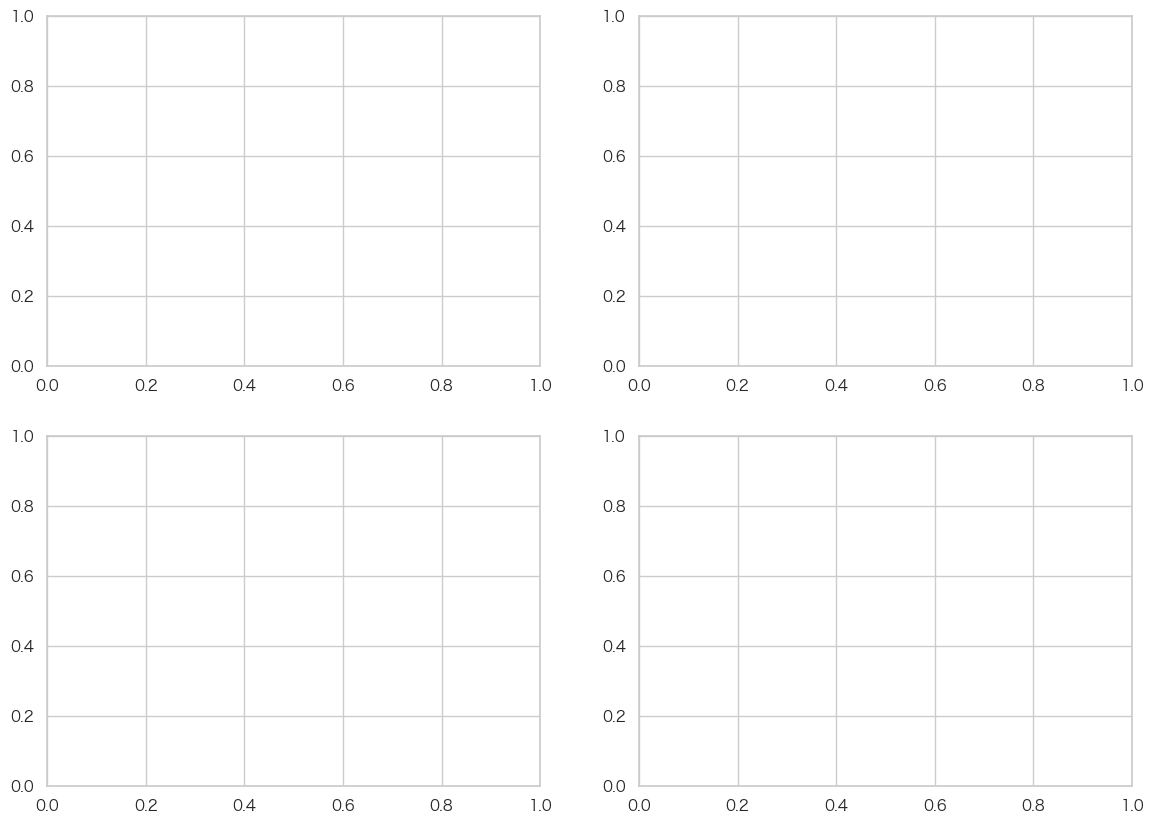

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
# 注意：sns.set_theme 会重置 rcParams，必须在其后再设置中文字体，否则会被覆盖导致中文显示为方框
plt.rcParams["font.sans-serif"] = ["Hiragino Sans GB", "PingFang HK", "Arial Unicode MS", "Heiti SC"]
plt.rcParams["axes.unicode_minus"] = False

plot_df = group_summary_df.copy()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=plot_df, x="variant_list", y="曝光后勾选率", ax=axes[0, 0], palette="Blues_d")
axes[0, 0].set_title("曝光后勾选率")

sns.barplot(data=plot_df, x="variant_list", y="顺手买渗透率", ax=axes[0, 1], palette="Greens_d")
axes[0, 1].set_title("顺手买渗透率（顺手买成功UV / 命中实验用户数）")

sns.barplot(data=plot_df, x="variant_list", y="顺手买GMV占比", ax=axes[1, 0], palette="Oranges_d")
axes[1, 0].set_title("顺手买GMV占比")

sns.barplot(data=plot_df, x="variant_list", y="人均订单GMV", ax=axes[1, 1], palette="Purples_d")
axes[1, 1].set_title("人均订单GMV")

plt.tight_layout()
plt.savefig("./data/grab_one_ab_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
